# Algorithms for large and sparse matrices

Let $A$ be an order $n\times n$ matrix.

By *large* we mean that $O(n^3)$ is too expensive or $A$ cannot be stored in memory.

By *sparse* we historically mean most entries are zero. A more modern defintion is that matrix-vector multiplications are $O(n)$.

example: low-rank matrix matrices.

Power Method: for starting vector $x$, find $x, Ax, A^2x, \ldots, A^kx$ 

$A^kx\approx$ eigenvector with the largest eigenvalue

## Krylov Subspace:

$\kappa_{k+1}(A,x) = \text{span}\{x, Ax, A^2x, \ldots, A^kx\}$

This subspace is key in two very important algorithms:

Arnoldi, for eigenvalues/vectors

Conjugate Gradient, for linear systems and leans squares problems.

Using Gram-Schmidt, we can find an orthonormal basis $\{q_1,q_2,\ldots,x_{k+1}\}$ for $\kappa_{k+1}(A,x)$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

In [2]:
def arnoldi(A,x, k):
    
    #initialize matrix Q
    
    Q = x.copy().reshape(-1,1)/np.linalg.norm(x)
    
    # initialize Matrix H
    
    H = np.array([])
    
    for i in range(k):
        # multiply last column of Q by A
        q = A.dot(Q[:,-1])
        # orthogonalize q against columns of Q
        h = Q.T.dot(q)
        q = q-Q.dot(h)
        # for numerical stability, we re-orthogonalize:
        s = Q.T.dot(q)
        q = q-Q.dot(s)
        h = h+s
        # normalize q
        hh = np.linalg.norm(q)
        q=q/hh
        #update matrix Q
        Q = np.c_[Q,q]
        # update matrix H
        H = np.block([[H,h.reshape(-1,1)],[np.zeros((1,i)),hh]])
        
    return H,Q

In [3]:
# cehck that it works
A =np.random.randn(10,10)

x = np.random.randn(10)

k = 4

H,Q = arnoldi(A,x,k)

In [4]:
np.linalg.norm(A.dot(Q[:,0:k])-Q.dot(H))

8.963804843917313e-16

In [5]:
from scipy.io import mmread # it reads matrices from the matrix market

In [6]:
A = mmread('west0479.mtx.gz')

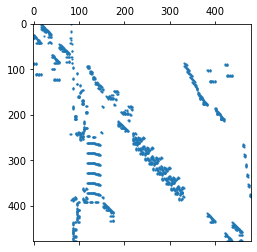

In [7]:
# display nonzero entries of A
plt.spy(A,markersize=1)

In [8]:
evalues, _ = np.linalg.eig(A.toarray())

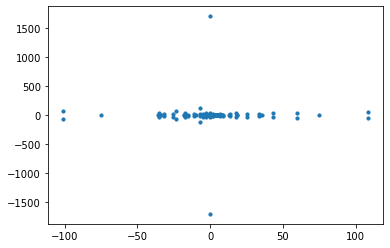

In [9]:
# plot eigenvalues

plt.scatter(evalues.real,evalues.imag,s=10)

In [10]:
n = A.shape[0]
#starting vector
x = np.random.randn(n)

# dimension of Krylov subspace
k = 20

#Arnoldi
H,Q = arnoldi(A,x,k)

In [11]:
Hhat = H[0:k,0:k]
# Ritz values
ritzvalues, _ = np.linalg.eig(Hhat)
# 10 largest Ritz values

ind = np.argsort(np.abs(ritzvalues))[::-1]

ritzvalues = ritzvalues[ind][0:10]

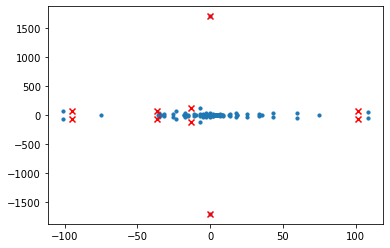

In [12]:
# plot ritz values / eigenvalues of A
plt.scatter(evalues.real,evalues.imag,s=10)
plt.scatter(ritzvalues.real,ritzvalues.imag,color='red',marker='x')

In [13]:
def shift_and_invert_arnoldi(A,x,k,shift):
    from scipy.sparse.linalg import factorized
    from scipy.sparse import identity
    
    #initialize matrix Q
    
    Q = x.copy().reshape(-1,1)/np.linalg.norm(x)
    
    # initialize Matrix H
    
    H = np.array([])
    
    # LU factorization of A-shift I
    n = A.shape[0]
    
    solver = factorized(A-shift*identity(n))
    
    for i in range(k):
        # multiply last column of Q by (A - shift*I)^{-1}
        q = solver(Q[:,-1])
        # orthogonalize q against columns of Q
        h = Q.conj().dot(q)
        q = q-Q.dot(h)
        # for numerical stability, we re-orthogonalize:
        s = Q.conj().dot(q)
        q = q-Q.dot(s)
        h = h+s
        # normalize q
        hh = np.linalg.norm(q)
        q=q/hh
        #update matrix Q
        Q = np.c_[Q,q]
        # update matrix H
        H = np.block([[H,h.reshape(-1,1)],[np.zeros((1,i)),hh]])
        
    return H,Q

(-10.0, 10.0)

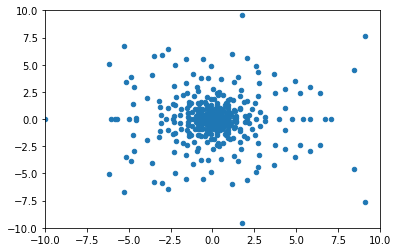

In [14]:
plt.scatter(evalues.real, evalues.imag, s=20)
plt.xlim([-10,10])
plt.ylim([-10,10])

In [15]:
shift = 6+1j*0

# dimension of the Krylov subspace

k = 50

# random vector

x = np.random.randn(n)

# shift and invert arnoldi

H,Q = shift_and_invert_arnoldi(A,x,k,shift)



/Users/vanmagnan/opt/anaconda3/lib/python3.8/site-packages/scipy/sparse/linalg/dsolve/linsolve.py:318: SparseEfficiencyWarning: splu requires CSC matrix format
  warn('splu requires CSC matrix format', SparseEfficiencyWarning)


ValueError: shapes (479,1) and (479,) not aligned: 1 (dim 1) != 479 (dim 0)

In [ ]:
Hhat = H[0:k,0:k]
# Ritz values
ritzvalues, _ = np.linalg.eig(Hhat)
# 10 largest Ritz values

ind = np.argsort(np.abs(ritzvalues))[::-1]

ritzvalues = ritzvalues[ind][0:10]
# undo shift and ivnert
ritzvalues = shift + 1/ritzvalues

In [ ]:
# plot ritz values / eigenvalues of A
plt.scatter(evalues.real,evalues.imag,s=10)
plt.scatter(ritzvalues.real,ritzvalues.imag,color='red',marker='x')
plt.xlim([-10,10])
plt.ylim([-10,10])

In [ ]:
plt.scatter(evalues.real, evalues.imag, s=20)
plt.xlim([-10,10])
plt.ylim([-10,10])

In [ ]:
shift = -3-5j

# dimension of the Krylov subspace

k = 50

# random vector

x = np.random.randn(n)

# shift and invert arnoldi

H,Q = shift_and_invert_arnoldi(A,x,k,shift)

Hhat = H[0:k,0:k]
# Ritz values
ritzvalues, _ = np.linalg.eig(Hhat)
# 10 largest Ritz values

ind = np.argsort(np.abs(ritzvalues))[::-1]

ritzvalues = ritzvalues[ind][0:10]
# undo shift and ivnert
ritzvalues = shift + 1/ritzvalues

In [ ]:
# plot ritz values / eigenvalues of A
plt.scatter(evalues.real,evalues.imag,s=10)
plt.scatter(ritzvalues.real,ritzvalues.imag,color='red',marker='x')
plt.xlim([-10,10])
plt.ylim([-10,10])